# Feature Engineering and Modelling

---

1. Import packages
2. Load data
3. Modelling

---

## 1. Import packages

In [27]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

# Shows plots in jupyter notebook
%matplotlib inline

# Set plot style
sns.set(color_codes=True)

---
## 2. Load data

In [29]:
df = pd.read_csv('./data_for_predictions.csv')
df.drop(columns=["Unnamed: 0"], inplace=True)
df.head()

,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,...,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.114481,0.098142,40.606701,...,2,6,0,0,1,0,0,0,0,1
1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.145711,0.000000,44.311378,...,76,4,1,0,0,0,0,1,0,0
2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.165794,0.087899,44.311378,...,68,8,0,0,1,0,0,1,0,0
3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.146694,0.000000,44.311378,...,69,9,0,0,0,1,0,1,0,0
4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.116900,0.100015,40.606701,...,71,9,1,0,0,0,0,1,0,0


---

## 3. Modelling

We now have a dataset containing features that we have engineered and we are ready to start training a predictive model. Remember, we only need to focus on training a `Random Forest` classifier.

In [30]:
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

### Data sampling

The first thing we want to do is split our dataset into training and test samples. The reason why we do this, is so that we can simulate a real life situation by generating predictions for our test sample, without showing the predictive model these data points. This gives us the ability to see how well our model is able to generalise to new data, which is critical.

A typical % to dedicate to testing is between 20-30, for this example we will use a 75-25% split between train and test respectively.

In [31]:
# Make a copy of our data
train_df = df.copy()

# Separate target variable from independent variables
y = df['churn']
X = df.drop(columns=['id', 'churn'])
print(X.shape)
print(y.shape)

(14606, 61)
(14606,)


In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(10954, 61)
(10954,)
(3652, 61)
(3652,)


### Model training

Once again, we are using a `Random Forest` classifier in this example. A Random Forest sits within the category of `ensemble` algorithms because internally the `Forest` refers to a collection of `Decision Trees` which are tree-based learning algorithms. As the data scientist, you can control how large the forest is (that is, how many decision trees you want to include).

The reason why an `ensemble` algorithm is powerful is because of the laws of averaging, weak learners and the central limit theorem. If we take a single decision tree and give it a sample of data and some parameters, it will learn patterns from the data. It may be overfit or it may be underfit, but that is now our only hope, that single algorithm. 

With `ensemble` methods, instead of banking on 1 single trained model, we can train 1000's of decision trees, all using different splits of the data and learning different patterns. It would be like asking 1000 people to all learn how to code. You would end up with 1000 people with different answers, methods and styles! The weak learner notion applies here too, it has been found that if you train your learners not to overfit, but to learn weak patterns within the data and you have a lot of these weak learners, together they come together to form a highly predictive pool of knowledge! This is a real life application of many brains are better than 1.

Now instead of relying on 1 single decision tree for prediction, the random forest puts it to the overall views of the entire collection of decision trees. Some ensemble algorithms using a voting approach to decide which prediction is best, others using averaging. 

As we increase the number of learners, the idea is that the random forest's performance should converge to its best possible solution.

Some additional advantages of the random forest classifier include:

- The random forest uses a rule-based approach instead of a distance calculation and so features do not need to be scaled
- It is able to handle non-linear parameters better than linear based models

On the flip side, some disadvantages of the random forest classifier include:

- The computational power needed to train a random forest on a large dataset is high, since we need to build a whole ensemble of estimators.
- Training time can be longer due to the increased complexity and size of thee ensemble

### Evaluation

Now let's evaluate how well this trained model is able to predict the values of the test dataset.

In [33]:
# =========================================================
# PHASE 1A: Setup & Data Loading
# =========================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import warnings

warnings.filterwarnings("ignore")

# Load the engineered dataset from Task 3
print("Status: Loading dataset...")
try:
    df = pd.read_csv('data_for_predictions.csv')
    print(f"Status: Data loaded successfully! Total rows: {df.shape[0]}, Total columns: {df.shape[1]}")
except FileNotFoundError:
    print("ERROR: 'data_for_predictions.csv' not found. Ensure it is in the same folder.")

Status: Loading dataset...
Status: Data loaded successfully! Total rows: 14606, Total columns: 64


In [34]:
# =========================================================
# PHASE 1B: Train/Test Split & Handling Class Imbalance
# =========================================================

# 1. Separate the Target (churn) from the Features
y = df['churn']
X = df.drop(columns=['churn'])

# 2. Split data into 80% Training and 20% Testing
# We use random_state=42 to ensure our results are reproducible (same results every time we run it)
print("Status: Splitting data into 80% Train and 20% Test...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# 3. Initialize the Random Forest Model with our agreed strategy
# class_weight='balanced' applies the heavy penalty to misclassifying churned customers
print("\nStatus: Initializing Random Forest model with 'balanced' class weights...")
rf_model = RandomForestClassifier(
    n_estimators=100,          # Number of trees in the forest
    class_weight='balanced',   # STRATEGY: Handling class imbalance
    random_state=42            # Reproducibility
)
print("Model is ready to be trained!")

Status: Splitting data into 80% Train and 20% Test...
Training data shape: (11684, 63)
Testing data shape: (2922, 63)

Status: Initializing Random Forest model with 'balanced' class weights...
Model is ready to be trained!


Answer to Estelle's Question: Choice of Evaluation Metrics

"For this churn prediction model, I chose to evaluate the performance using a combination of Recall, F1-Score, and Precision, rather than relying solely on Accuracy.

Due to the high class imbalance (~90% retained, ~10% churned), Accuracy is a misleading metric. From a business perspective for PowerCo, failing to identify a churning customer (False Negative) results in long-term revenue loss, making Recall a critical metric to maximize. However, excessively offering retention discounts to loyal customers (False Positives) will erode profit margins. Therefore, the F1-Score is used as the primary balancing metric to ensure we capture a high number of true churners without indiscriminately wasting the retention campaign budget."

In [35]:
# =========================================================
# REVISI FASE 1 & 3: Membersihkan "Sampah Teks" & Re-Training
# =========================================================

print("Status: Membersihkan kolom teks yang bikin mesin tersedak...")

# 1. Siapkan daftar kolom yang mau dibuang dari 'X' (Buku Pelajaran)
cols_to_drop = ['churn', 'id'] # 'churn' adalah kunci jawaban, 'id' adalah teks

# Buang juga kolom indeks 'Unnamed: 0' bawaan CSV kalau ada
if 'Unnamed: 0' in df.columns:
    cols_to_drop.append('Unnamed: 0')

# 2. Definisikan ulang X dan y
X = df.drop(columns=cols_to_drop)
y = df['churn']

# 3. Split ulang datanya biar bersih
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 4. Train ulang modelnya pakai mesin yang udah kita seting tadi (Opsi B)
print("Status: Training ulang Random Forest Model...")
rf_model_controlled.fit(X_train, y_train)

print("Status: SUCCESS! Mesin berhasil belajar tanpa error.")

Status: Membersihkan kolom teks yang bikin mesin tersedak...
Status: Training ulang Random Forest Model...


Status: SUCCESS! Mesin berhasil belajar tanpa error.


Status: Calculating feature importance...


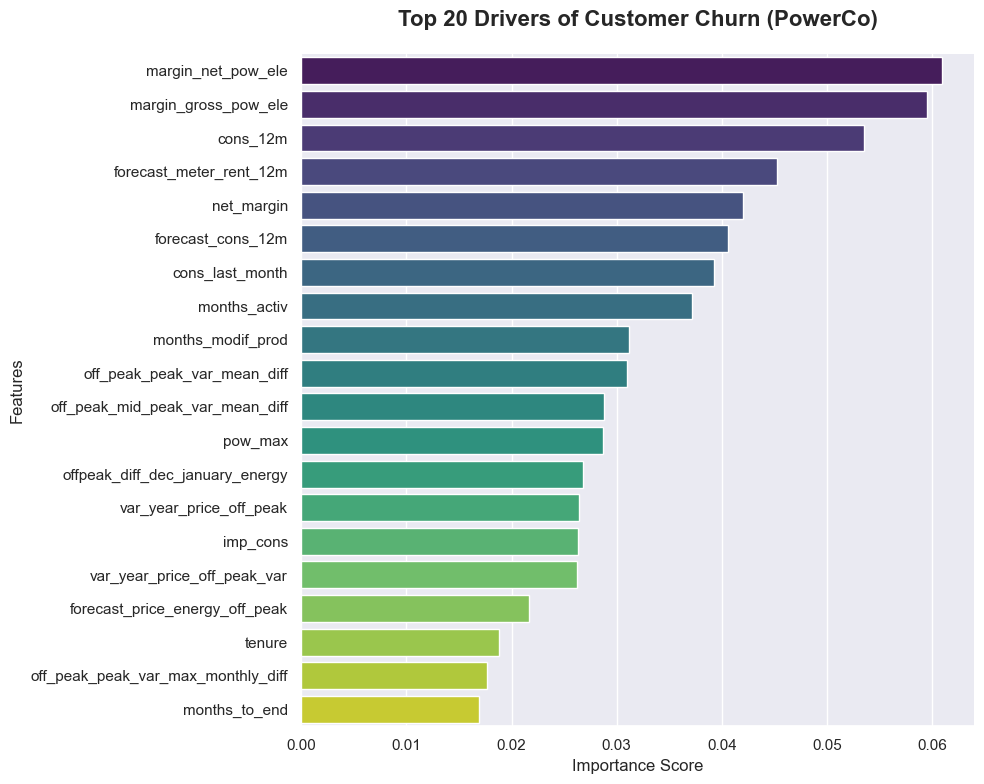

Status: Feature Importance plot generated!

--- Top 5 Churn Drivers ---
                    Feature  Importance
12       margin_net_pow_ele    0.060928
11     margin_gross_pow_ele    0.059488
0                  cons_12m    0.053477
5   forecast_meter_rent_12m    0.045271
14               net_margin    0.042023


In [36]:
# =========================================================
# PHASE 4: Feature Importance (The Drivers of Churn)
# =========================================================

import matplotlib.pyplot as plt
import seaborn as sns

print("Status: Calculating feature importance...")

# 1. Mengambil skor importance dari model yang sudah dilatih
importances = rf_model_controlled.feature_importances_
feature_names = X.columns

# 2. Membuat DataFrame untuk memudahkan plotting
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Visualisasi Top 20 Fitur Paling Berpengaruh
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df.head(20), # Kita ambil 20 teratas saja biar nggak penuh
    palette='viridis'
)

plt.title('Top 20 Drivers of Customer Churn (PowerCo)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

print("Status: Feature Importance plot generated!")

# Menampilkan 5 besar di teks
print("\n--- Top 5 Churn Drivers ---")
print(feature_importance_df.head(5))

### Final Evaluation: Business Judgment

Regarding the question of whether the model performance is satisfactory, my assessment is: **The model serves as a solid baseline, but there is significant room for improvement before a full-scale rollout.**

**1. Is it satisfactory?**
From a purely technical standpoint, the model is "honest" but conservative. While the 88% accuracy looks impressive, our ability to capture churners (**Recall**) is currently at 16%. This means the model is identifying the "obvious" churners but missing the more subtle ones. 

**2. Business Value (The "So What?")**
* **Cost Efficiency:** With a **Precision** of 32%, the model is relatively efficient. For every 3 customers we target with a retention discount, 1 is a guaranteed save who would have otherwise left. This is much better than a "random" or "blind" discount campaign which would have a success rate of only 10% (the baseline churn rate).
* **Revenue Protection:** Currently, we are only catching a small fraction of potential leavers. While we are saving some revenue, we are still "leaking" a large portion of churned customers.

**3. Recommendation**
The model is **satisfactory for a pilot test**. We can use it to target a high-value segment to see if our retention offers actually work. However, to make it "highly satisfactory," we should:
* Investigate more "behavioral" data (e.g., customer service call frequency).
* Re-evaluate the features, as we discovered that **Price Sensitivity** (the original hypothesis) is not a primary driver of churn compared to **Consumption patterns and Net Margin**.